In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [25]:
df = pd.read_csv('experiment_results_tuned.csv')

display(df)

,experiment,classifier,train_language,test_language,n_train,n_test,accuracy,f1_weighted,best_params
0,mandarin_to_mandarin,logistic_regression,mandarin,mandarin,14000,3500,0.945143,0.945232,"{'clf__C': 0.1, 'clf__class_weight': None}"
1,mandarin_to_mandarin,linear_svm,mandarin,mandarin,14000,3500,0.949429,0.949436,"{'clf__C': 0.1, 'clf__class_weight': None}"
2,mandarin_to_mandarin,mlp,mandarin,mandarin,14000,3500,0.941143,0.941261,"{'clf__alpha': 0.01, 'clf__hidden_layer_sizes'..."
3,english_to_english,logistic_regression,english,english,14000,3500,0.927143,0.926753,"{'clf__C': 0.1, 'clf__class_weight': None}"
4,english_to_english,linear_svm,english,english,14000,3500,0.925429,0.925080,"{'clf__C': 0.1, 'clf__class_weight': None}"
5,english_to_english,mlp,english,english,14000,3500,0.946000,0.945965,"{'clf__alpha': 0.01, 'clf__hidden_layer_sizes'..."
6,mandarin_to_english,logistic_regression,mandarin,english,17500,17500,0.522686,0.510912,"{'clf__C': 0.1, 'clf__class_weight': None}"
7,mandarin_to_english,linear_svm,mandarin,english,17500,17500,0.532743,0.517993,"{'clf__C': 0.01, 'clf__class_weight': None}"
8,mandarin_to_english,mlp,mandarin,english,17500,17500,0.523371,0.516136,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."
9,english_to_mandarin,logistic_regression,english,mandarin,17500,17500,0.542000,0.491915,"{'clf__C': 0.01, 'clf__class_weight': None}"


In [26]:
df_logreg = df[df['classifier'] == 'logistic_regression']
df_linear_svm = df[df['classifier'] == 'linear_svm']
df_mlp = df[df['classifier'] == 'mlp']

df_list = list([df_logreg, df_linear_svm, df_mlp])
df_list

[             experiment           classifier train_language test_language  \
 0  mandarin_to_mandarin  logistic_regression       mandarin      mandarin   
 3    english_to_english  logistic_regression        english       english   
 6   mandarin_to_english  logistic_regression       mandarin       english   
 9   english_to_mandarin  logistic_regression        english      mandarin   
 
    n_train  n_test  accuracy  f1_weighted  \
 0    14000    3500  0.945143     0.945232   
 3    14000    3500  0.927143     0.926753   
 6    17500   17500  0.522686     0.510912   
 9    17500   17500  0.542000     0.491915   
 
                                    best_params  
 0   {'clf__C': 0.1, 'clf__class_weight': None}  
 3   {'clf__C': 0.1, 'clf__class_weight': None}  
 6   {'clf__C': 0.1, 'clf__class_weight': None}  
 9  {'clf__C': 0.01, 'clf__class_weight': None}  ,
               experiment  classifier train_language test_language  n_train  \
 1   mandarin_to_mandarin  linear_svm       ma

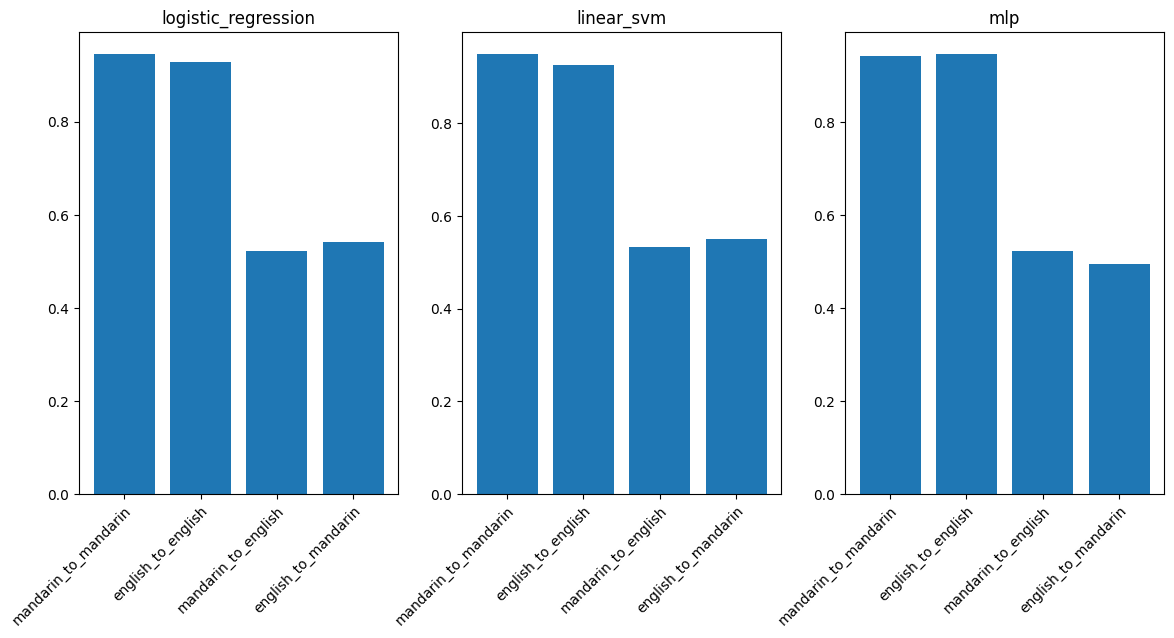

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(14, 6))


for i, df_ in enumerate(df_list):
    ax[i].bar(df_['experiment'], df_['accuracy'])
    
    ax[i].set_xticks(range(len(df_['experiment'])))
    
    ax[i].set_xticklabels(
        df_['experiment'], 
        rotation=45, 
        ha='right', 
        rotation_mode='anchor'
    )

    ax[i].set_title(df_['classifier'].iloc[0])




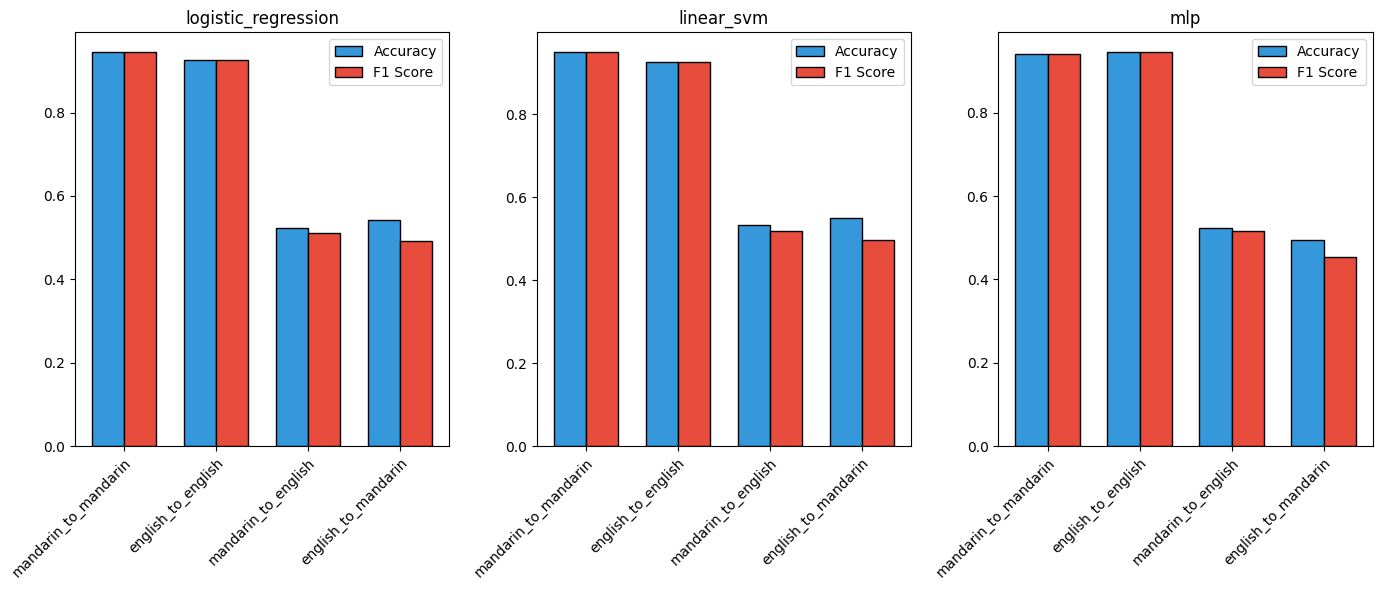

In [ ]:
width = 0.35  # Set the width of each bar

fig, ax = plt.subplots(1, 3, figsize=(14, 6))

for i, df_ in enumerate(df_list):
    x = np.arange(len(df_['experiment'])) 
    
    ax[i].bar(x - width/2, df_['accuracy'], width, 
              label='Accuracy', color='#3498db', edgecolor='black')

    ax[i].bar(x + width/2, df_['f1_weighted'], width, 
              label='F1 Score', color='#e74c3c', edgecolor='black')

    ax[i].set_xticks(x) 
    ax[i].set_xticklabels(df_['experiment'])

    plt.setp(ax[i].get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    ax[i].set_title(df_['classifier'].iloc[0])

    ax[i].legend()

fig.tight_layout()

